<a href="https://colab.research.google.com/github/miriam-silva/ProvaIcomaAM/blob/main/prova_01_miriam_silva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prova 01:** IBM | Direção Diária:

**Alvo ($Y$):** 1 se Fechamento > Abertura; 0 caso contrário.

**Desafio:** O Naive Bayes prevê altas apenas com base nas variações passadas?

# **Aluna:** Miriam Silva Corrêa



# Pipeline 1 | Extração de Dados [Fase 1]

## Bibliotecas

In [1]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Consumo da API (Alpha Vantage)

In [2]:
API_KEY = 'N1G1G2NZBJN7L7J9'
symbol = 'IBM'
url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&apikey={API_KEY}&outputsize=compact'
response = requests.get(url)
data = response.json()

## Transformação para DataFrame

In [3]:
if 'Time Series (Daily)' in data:
  df = pd.DataFrame.from_dict(data['Time Series (Daily)'], orient='index')
  df.columns = ['open', 'high', 'low', 'close', 'volume']
  df = df.astype(float)
  df.index = pd.to_datetime(df.index)
  df = df.sort_index()
  print("Dados carregados com sucesso!")
else:
  print("Erro na API:", data)

Dados carregados com sucesso!


In [4]:
df.head()

,open,high,low,close,volume
2025-12-10,310.230,314.6900,306.6513,312.67,3411524.0
2025-12-11,312.000,313.4400,308.4000,310.74,2755749.0
2025-12-12,310.570,311.0500,303.3300,309.24,2953374.0
2025-12-15,308.985,311.3629,306.3500,308.66,3566732.0
2025-12-16,307.315,307.3800,300.4200,303.18,3366878.0


# Pipeline 2 | Laborização (Feature Engineering) [Fase 2]

## Criação da Variável Alvo (Y)

In [5]:
df['target'] = (df['close'] > df['open']).astype(int)

## Criação de Preditores (X) baseados em Lags

In [6]:
df['variation'] = (df['close'] - df['open']) / df['open']
df['prev_variation'] = df['variation'].shift(1)
df['prev_variation_2'] = df['variation'].shift(2)
df['prev_variation_3'] = df['variation'].shift(3)
df['volume_log'] = np.log1p(df['volume'])

df['prev_volume'] = df['volume_log'].shift(1)
df['prev_volume_2'] = df['volume_log'].shift(2)

df_final = df[['prev_variation', 'prev_variation_2', 'prev_variation_3', 'prev_volume', 'prev_volume_2', 'target']].dropna()

print("Colunas extras removidas e valores nulos excluídos.")
df_final.head()

Colunas extras removidas e valores nulos excluídos.


,prev_variation,prev_variation_2,prev_variation_3,prev_volume,prev_volume_2,target
2025-12-15,-0.004282,-0.004038,0.007865,14.898459,14.829200,0
2025-12-16,-0.001052,-0.004282,-0.004038,15.087161,14.898459,0
2025-12-17,-0.013455,-0.001052,-0.004282,15.029497,15.087161,0
2025-12-18,-0.001547,-0.013455,-0.001052,14.956849,15.029497,0
2025-12-19,-0.008906,-0.001547,-0.013455,15.504068,14.956849,1


# Pipeline 3 | Tratamento e Normalização [Fase 3]

In [7]:
df_final.head()

,prev_variation,prev_variation_2,prev_variation_3,prev_volume,prev_volume_2,target
2025-12-15,-0.004282,-0.004038,0.007865,14.898459,14.829200,0
2025-12-16,-0.001052,-0.004282,-0.004038,15.087161,14.898459,0
2025-12-17,-0.013455,-0.001052,-0.004282,15.029497,15.087161,0
2025-12-18,-0.001547,-0.013455,-0.001052,14.956849,15.029497,0
2025-12-19,-0.008906,-0.001547,-0.013455,15.504068,14.956849,1


## Verificação de valores nulos

In [8]:
df_final.isnull().sum()

,0
prev_variation,0
prev_variation_2,0
prev_variation_3,0
prev_volume,0
prev_volume_2,0
target,0


## Estatísticas descritivas

In [9]:
df_final.describe()

,prev_variation,prev_variation_2,prev_variation_3,prev_volume,prev_volume_2,target
count,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,-0.002730,-0.002660,-0.002475,15.433433,15.429583,0.494845
std,0.021682,0.021666,0.021679,0.462973,0.466451,0.502571
min,-0.121948,-0.121948,-0.121948,14.006662,14.006662,0.000000
25%,-0.010509,-0.010412,-0.010412,15.144982,15.144513,0.000000
50%,-0.000034,-0.000034,0.000216,15.395254,15.395254,0.000000
75%,0.009045,0.009045,0.009045,15.640001,15.640001,1.000000
max,0.037783,0.037783,0.037783,16.920000,16.920000,1.000000


## Remoção de Outliers

In [10]:
df_final = df_final[
    (np.abs(df_final['prev_variation']) < 3 * df_final['prev_variation'].std()) &
    (np.abs(df_final['prev_variation_2']) < 3 * df_final['prev_variation_2'].std()) &
    (np.abs(df_final['prev_variation_3']) < 3 * df_final['prev_variation_3'].std())
]

## Seleção de Variáveis (X e y)

In [11]:
X = df_final[['prev_variation', 'prev_variation_2', 'prev_variation_3', 'prev_volume', 'prev_volume_2']]
y = df_final['target']

## Análise de Balanceamento das Classes

In [12]:
print(y.value_counts())

target
0    47
1    44
Name: count, dtype: int64


## Divisão Treino/Teste

In [13]:
tamanho = int(len(X)*0.8)

X_train = X[:tamanho]
X_test = X[tamanho:]

y_train = y[:tamanho]
y_test = y[tamanho:]

## Normalização (StandardScaler)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Pipeline 4 | Visualização de Dados [Fase 4]

## Gráficos de Fechamento e Volume

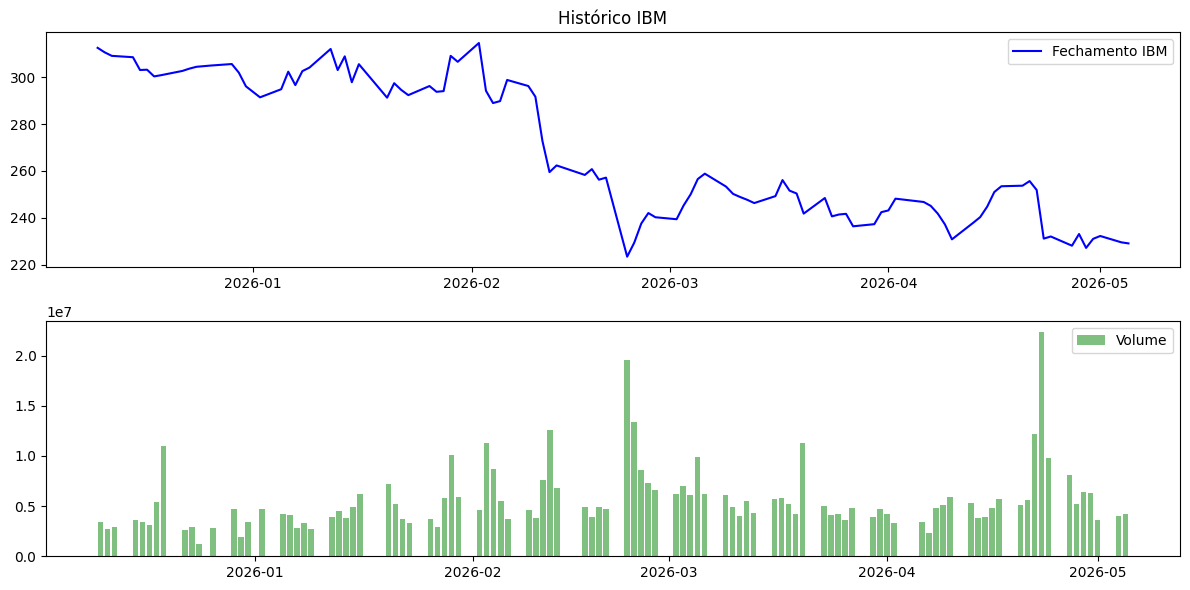

In [15]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(df.index, df['close'], color='blue' , label='Fechamento IBM')
plt.title('Histórico IBM')
plt.legend()

plt.subplot(2, 1, 2)
plt.bar(df.index, df['volume'], color='green', alpha=0.5, label='Volume')
plt.legend()

plt.tight_layout()
plt.show()

# Pipeline 5 | Ingestão Bayesiana [Fase 5]

## Treinamento do Modelo (GaussianNB)

In [16]:
modelo = GaussianNB()
modelo.fit(X_train, y_train)

GaussianNB()

## Previsão

In [17]:
y_pred = modelo.predict(X_test)

## Avaliação do Modelo e Matriz de Confusão

Acurácia: 63.16%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.70      0.64      0.67        11
           1       0.56      0.62      0.59         8

    accuracy                           0.63        19
   macro avg       0.63      0.63      0.63        19
weighted avg       0.64      0.63      0.63        19



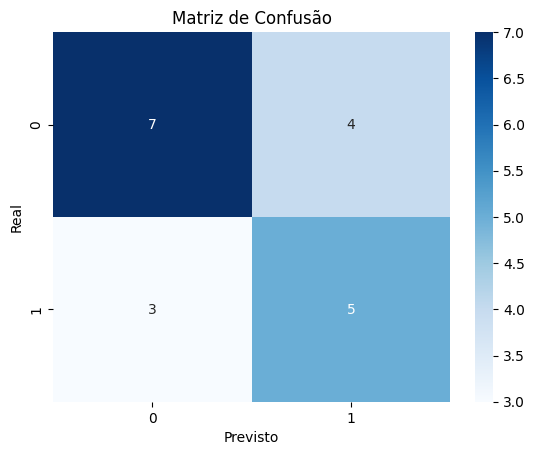

In [18]:
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()